In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [196]:
TRAIN_FILE = "train-test.csv"
VALIDATION_FILE = "validation.csv"
TEMPLATE_FILE = "validation-predictions-template.csv"
DECEMBER_FILE = "december-chart-inputs.csv"

In [197]:
"""
  - What does each column contain?
  - Are there missing, duplicated, or invalid values?
  - Which features influence posted_rate?
  - Are there outliers?
  - Does pricing change by distance, equipment, route, or date?
"""

'\n  - What does each column contain?\n  - Are there missing, duplicated, or invalid values?\n  - Which features influence posted_rate?\n  - Are there outliers?\n  - Does pricing change by distance, equipment, route, or date?\n'

In [198]:
# load the training and validation dataset
train = pd.read_csv(TRAIN_FILE)
validation = pd.read_csv(VALIDATION_FILE)

In [199]:
pd.set_option("display.max_columns", None)

In [200]:
print(train.shape)

(48000, 14)


In [201]:
print(validation.shape)

(12000, 13)


In [202]:
print(train.head())

     load_id        pickup      delivery  pickup_lat  pickup_lon  \
0  TR-000001      Richmond     Baltimore    38.09122   -76.78906   
1  TR-000002      Richmond  Philadelphia    38.09122   -76.78906   
2  TR-000003  Philadelphia     Green Bay    39.22317   -72.96710   
3  TR-000004      Hartford       Atlanta    39.55328   -72.18051   
4  TR-000005        Dallas     Nashville    31.83025   -94.38343   

   delivery_lat  delivery_lon  distance equipment   weight        date  \
0      38.16908     -72.74564     274.3   Dry Van  30658.0  2025-01-01   
1      39.22317     -72.96710     280.5    Reefer  17555.0  2025-01-01   
2      44.30296     -87.52871     967.8   Dry Van  31721.0  2025-01-01   
3      34.84933     -86.28940     965.4   Dry Van  32333.0  2025-01-01   
4      35.29479     -88.08915     541.9    Reefer  35183.0  2025-01-01   

   market_index  quote_signal  posted_rate  
0       0.95684       2.39595       645.41  
1       0.97623       2.43355       679.97  
2       1.0

In [203]:
print(train.info())

<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  str    
 1   pickup        48000 non-null  str    
 2   delivery      48000 non-null  str    
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  str    
 9   weight        47700 non-null  float64
 10  date          48000 non-null  str    
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), str(5)
memory usage: 5.1 MB
None


In [204]:
print(validation.info())

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       12000 non-null  str    
 1   pickup        12000 non-null  str    
 2   delivery      12000 non-null  str    
 3   pickup_lat    12000 non-null  float64
 4   pickup_lon    12000 non-null  float64
 5   delivery_lat  12000 non-null  float64
 6   delivery_lon  12000 non-null  float64
 7   distance      12000 non-null  float64
 8   equipment     12000 non-null  str    
 9   weight        11835 non-null  float64
 10  date          12000 non-null  str    
 11  market_index  11751 non-null  float64
 12  quote_signal  12000 non-null  float64
dtypes: float64(8), str(5)
memory usage: 1.2 MB
None


In [205]:
print(train.describe(include="all").T)

"""
1. There are negative weights in training and validation data.
"""

                count unique            top   freq          mean          std  \
load_id         48000  48000      TR-000001      1           NaN          NaN   
pickup          48000     64  Oklahoma City   1242           NaN          NaN   
delivery        48000     64      Lexington   1197           NaN          NaN   
pickup_lat    48000.0    NaN            NaN    NaN     35.647545     4.315285   
pickup_lon    48000.0    NaN            NaN    NaN    -90.928964    13.482431   
delivery_lat  48000.0    NaN            NaN    NaN     35.641175     4.317199   
delivery_lon  48000.0    NaN            NaN    NaN     -90.85731    13.476589   
distance      48000.0    NaN            NaN    NaN   1135.856654   728.564416   
equipment       48000      3        Dry Van  27202           NaN          NaN   
weight        47700.0    NaN            NaN    NaN  31028.844004   9391.44062   
date            48000    304     2025-06-17    198           NaN          NaN   
market_index  47626.0    NaN

'\n1. There are negative weights in training and validation data.\n'

In [206]:
print(validation.describe(include="all").T)

                count unique          top  freq          mean          std  \
load_id         12000  12000    TE-000001     1           NaN          NaN   
pickup          12000     72    Lexington   301           NaN          NaN   
delivery        12000     72  Bakersfield   299           NaN          NaN   
pickup_lat    12000.0    NaN          NaN   NaN     35.574216     4.366999   
pickup_lon    12000.0    NaN          NaN   NaN     -90.72488    13.411638   
delivery_lat  12000.0    NaN          NaN   NaN     35.609538     4.351844   
delivery_lon  12000.0    NaN          NaN   NaN     -90.91353    13.624744   
distance      12000.0    NaN          NaN   NaN     1141.7731   732.333797   
equipment       12000      3      Dry Van  6780           NaN          NaN   
weight        11835.0    NaN          NaN   NaN  30506.636248  10572.59045   
date            12000     61   2025-12-19   227           NaN          NaN   
market_index  11751.0    NaN          NaN   NaN      0.926913   

In [207]:
# print the count of negative values in "weights" (292)
print("Count of Negative Values in weight (train):", (train["weight"] < 0).sum())
print("Count of Negative Values in validation (validation):", (validation["weight"] < 0).sum())

print("Count of NaN Values in weight (train)", train["weight"].isna().sum())
print("Count of NaN Values in weight (validation)", validation["weight"].isna().sum())



Count of Negative Values in weight (train): 292
Count of Negative Values in validation (validation): 145
Count of NaN Values in weight (train) 300
Count of NaN Values in weight (validation) 165


In [208]:
# market_index
# print the count of negative values in "market_index"
print("Count of Negative Values in weight (train):", (train["market_index"] < 0).sum())
print("Count of Negative Values in validation (validation):", (validation["market_index"] < 0).sum())

# print the count of NaN values in "market_index"
print("Count of NaN Values in weight (train)", train["market_index"].isna().sum())
print("Count of NaN Values in weight (validation)", validation["market_index"].isna().sum())



Count of Negative Values in weight (train): 0
Count of Negative Values in validation (validation): 0
Count of NaN Values in weight (train) 374
Count of NaN Values in weight (validation) 249


In [209]:
# check null values
print(train.isna().sum())
print(validation.isna().sum())

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          165
date              0
market_index    249
quote_signal      0
dtype: int64


In [210]:
# dealing with NaN and Negative weight values
"""
For weight, grouped median by equipment is reasonable
"""
equipment_mean_rate = (
      train.groupby("equipment")["weight"]
      .mean()
      .sort_values(ascending=False)
  )

print(equipment_mean_rate)

equipment
Reefer     31079.714572
Dry Van    31027.293447
Flatbed    30963.625776
Name: weight, dtype: float64


In [211]:
numeric_columns = [
    "pickup_lat", 
    "pickup_lon",
    "delivery_lat", 
    "delivery_lon",
    "distance", 
    "weight",
    "market_index", 
    "quote_signal",
    "posted_rate"
]

for column in numeric_columns:
    print(
        column, ":", "min = ", train[column].min(),
        "max = ", train[column].max(),
        "invalid = ", (~np.isfinite(train[column])).sum(),
    )

pickup_lat : min =  28.35765 max =  44.30296 invalid =  0
pickup_lon : min =  -121.69849 max =  -69.5 invalid =  0
delivery_lat : min =  28.35765 max =  44.30296 invalid =  0
delivery_lon : min =  -121.69849 max =  -69.5 invalid =  0
distance : min =  70.0 max =  3439.8 invalid =  0
weight : min =  -47500.0 max =  47500.0 invalid =  300
market_index : min =  0.67639 max =  1.46778 invalid =  374
quote_signal : min =  0.69228 max =  3.61035 invalid =  0
posted_rate : min =  57.22 max =  25533.0 invalid =  0


In [212]:
print("Duplicate training rows:", train.duplicated().sum())
print("Duplicate load IDs:", train["load_id"].duplicated().sum())
print("Duplicate validation IDs:", validation["load_id"].duplicated().sum())

print(train["load_id"].str[:2].value_counts())
print(validation["load_id"].str[:2].value_counts())

Duplicate training rows: 0
Duplicate load IDs: 0
Duplicate validation IDs: 0
load_id
TR    48000
Name: count, dtype: int64
load_id
TE    12000
Name: count, dtype: int64


In [213]:
# explore categorical columns: pickup, delivery, equipment
categorical_columns = ["pickup", "delivery", "equipment"]

for column in categorical_columns:
    print(f"\n{column}", "Unique values:", train[column].nunique())
    # print()
    print(train[column].value_counts().head(10))


pickup Unique values: 64
pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
Richmond         1140
Nashville        1124
Phoenix          1121
Baton Rouge      1115
Mobile           1094
Name: count, dtype: int64

delivery Unique values: 64
delivery
Lexington        1197
Fort Wayne       1176
Baton Rouge      1167
Bakersfield      1156
Hartford         1143
Oklahoma City    1140
Richmond         1109
Atlanta          1096
Phoenix          1090
Mobile           1089
Name: count, dtype: int64

equipment Unique values: 3
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64


In [214]:
for column in categorical_columns:
    summary = (
        train.groupby(column)["posted_rate"]
        .agg(["count", "mean", "median", "min", "max"])
        .sort_values("mean", ascending=False)
      )
    print(f"\nPosted rate by {column}")
    print(summary.head(10))


Posted rate by pickup
                count         mean    median     min       max
pickup                                                        
San Francisco     453  4071.207108  4301.810  562.12  13409.18
Fresno            827  3878.910000  4160.280  171.28  13847.57
Reno              642  3765.391199  3836.925  426.62  23662.71
Phoenix          1121  3764.774764  3935.620  181.56  24294.98
Los Angeles       945  3729.638392  3996.610   63.36  24140.21
Bakersfield      1193  3519.365448  3804.880  193.34  25533.00
Tucson            944  3310.996271  3535.995  166.30  22755.66
Las Vegas         277  3292.821913  3633.060  288.07  12569.71
Salt Lake City    394  3144.764112  3316.265  244.05   6456.47
Providence        425  3134.073624  2603.080  424.18  14934.48



Posted rate by delivery
                count         mean    median     min       max
delivery                                                      
San Francisco     467  4064.472998  4356.600  556.94   6980.20
Fresno            763  3865.377156  4140.170  531.16  20361.89
Phoenix          1090  3751.473110  3921.980   63.36  23580.42
Los Angeles       955  3742.250932  4046.090  171.28  17772.53
Reno              653  3679.871639  3783.880  244.05  17688.63
Bakersfield      1156  3532.198893  3742.535  182.42  19110.30
Las Vegas         292  3428.375274  3707.765  304.19  11596.28
Tucson            997  3363.189789  3591.790  181.56  17893.17
Salt Lake City    406  3164.350788  3316.060  193.34  11668.74
El Paso           769  3008.979779  3089.550  184.26  14949.25

Posted rate by equipment
           count         mean    median     min       max
equipment                                                
Reefer     12045  2553.636939  2196.670   63.36  24140.21
Flatbed     8753  2

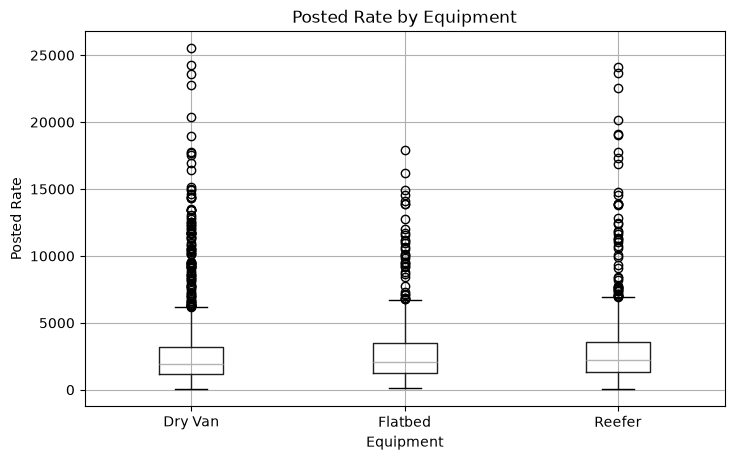

In [215]:
#   Equipment pricing is especially important:

train.boxplot(column="posted_rate", by="equipment", figsize=(8, 5))
plt.title("Posted Rate by Equipment")
plt.suptitle("")
plt.xlabel("Equipment")
plt.ylabel("Posted Rate")
plt.show()



count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64


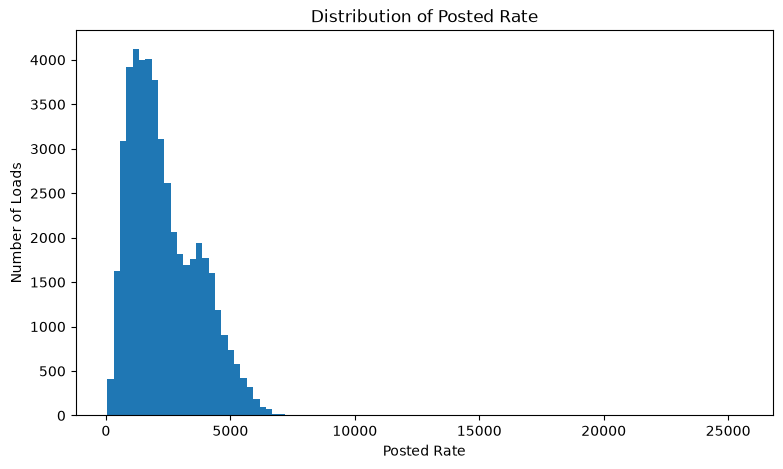

In [216]:
print(train["posted_rate"].describe())

plt.figure(figsize=(9, 5))
plt.hist(train["posted_rate"], bins=100)
plt.title("Distribution of Posted Rate")
plt.xlabel("Posted Rate")
plt.ylabel("Number of Loads")
plt.show()


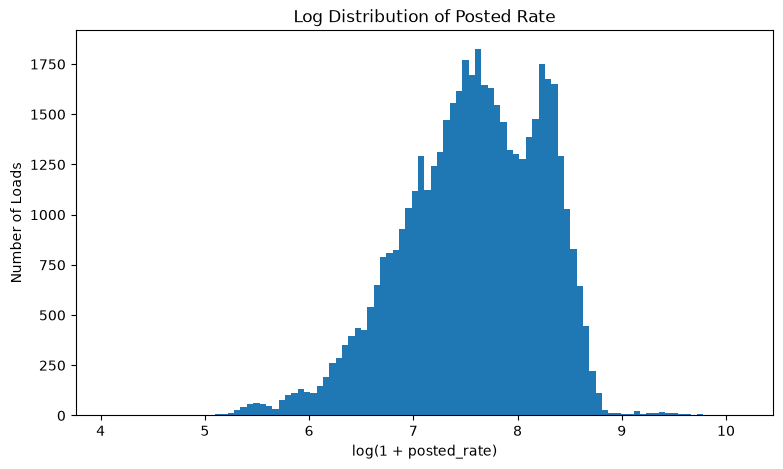

In [217]:
plt.figure(figsize=(9, 5))
plt.hist(np.log1p(train["posted_rate"]), bins=100)
plt.title("Log Distribution of Posted Rate")
plt.xlabel("log(1 + posted_rate)")
plt.ylabel("Number of Loads")
plt.show()

In [218]:
print(
    train.nlargest(10, "posted_rate")[
        ["load_id", "pickup", "delivery", "distance", "equipment", "weight", "posted_rate"]
    ]
)

         load_id       pickup       delivery  distance equipment   weight  \
12184  TR-012185  Bakersfield       Hartford    2829.8   Dry Van  33153.0   
37764  TR-037765      Phoenix       Syracuse    2810.9   Dry Van  33674.0   
1466   TR-001467  Los Angeles       Syracuse    2786.0    Reefer  30322.0   
17371  TR-017372         Reno   Philadelphia    2777.6    Reefer  33158.0   
26235  TR-026236   Charleston        Phoenix    2552.5   Dry Van  25665.0   
28219  TR-028220       Tucson        Raleigh    2423.3   Dry Van  30972.0   
3353   TR-003354      Phoenix     Charleston    2527.9    Reefer  36840.0   
40171  TR-040172   Montgomery         Fresno    2283.4   Dry Van  32447.0   
40096  TR-040097    Baltimore  Oklahoma City    1760.3    Reefer  29521.0   
47298  TR-047299       Boston    Bakersfield    2979.1    Reefer  30585.0   

       posted_rate  
12184     25533.00  
37764     24294.98  
1466      24140.21  
17371     23662.71  
26235     23580.42  
28219     22755.66  
3353 

In [219]:
numeric_columns = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]

print(train[numeric_columns].corr()["posted_rate"].sort_values())

quote_signal   -0.039858
market_index    0.034165
weight          0.034840
distance        0.908519
posted_rate     1.000000
Name: posted_rate, dtype: float64


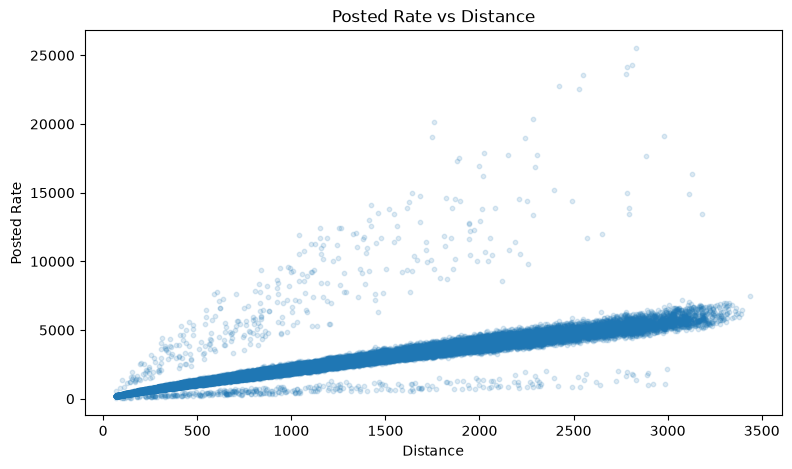

In [220]:
plt.figure(figsize=(9, 5))
plt.scatter(
    train["distance"],
    train["posted_rate"],
    alpha=0.15,
    s=10
)
plt.title("Posted Rate vs Distance")
plt.xlabel("Distance")
plt.ylabel("Posted Rate")
plt.show()

In [221]:
route_summary = (
      train.groupby(["pickup", "delivery"])["posted_rate"]
      .agg(["count", "mean", "median"])
      .sort_values("count", ascending=False)
  )

print(route_summary.head(20))



                             count         mean    median
pickup        delivery                                   
Lexington     Atlanta           39   560.106154   553.630
Phoenix       Shreveport        39  3507.618462  3554.430
Columbia      Oklahoma City     39  2330.734615  2327.430
Fort Wayne    Philadelphia      38  1681.032632  1708.835
Richmond      Oklahoma City     37  3093.435946  3126.490
Lexington     Kansas City       37  1042.474595  1029.800
Shreveport    Hartford          37  2867.768108  2812.520
Fort Wayne    Hartford          37  1938.657297  1725.990
Lexington     Cincinnati        37   396.691892   377.100
Richmond      Phoenix           37  5190.194595  5010.880
Fort Wayne    Cincinnati        36   871.521111   857.150
Mobile        Phoenix           36  4180.469167  3842.000
Richmond      Cincinnati        35  1472.597143  1445.430
Oklahoma City Atlanta           35  1895.603714  1909.990
Philadelphia  Lexington         35  1708.174857  1691.690
Columbia      

In [222]:
def haversine_miles(lat1, lon1, lat2, lon2):
      earth_radius = 3958.8

      lat1 = np.radians(lat1)
      lon1 = np.radians(lon1)
      lat2 = np.radians(lat2)
      lon2 = np.radians(lon2)

      dlat = lat2 - lat1
      dlon = lon2 - lon1

      a = (
          np.sin(dlat / 2) ** 2
          + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
      )

      return earth_radius * 2 * np.arcsin(np.sqrt(a))

train["great_circle_miles"] = haversine_miles(
      train["pickup_lat"],
      train["pickup_lon"],
      train["delivery_lat"],
      train["delivery_lon"]
  )

train["distance_difference"] = (
      train["distance"] - train["great_circle_miles"]
  )

print(
      train[
          ["distance", "great_circle_miles", "distance_difference"]
      ].describe()
  )


           distance  great_circle_miles  distance_difference
count  48000.000000        48000.000000         48000.000000
mean    1135.856654          966.154360           169.702294
std      728.564416          630.650711           100.072162
min       70.000000            7.265240             4.556779
25%      550.400000          456.537929            90.741713
50%      953.300000          806.935637           144.212569
75%     1645.525000         1410.670791           234.160251
max     3439.800000         2873.652583           581.665453


In [223]:
# data preprocessing
target = train["posted_rate"]

features = train.drop(
    columns=["posted_rate", "load_id", "date"]
)

print(features.head())

         pickup      delivery  pickup_lat  pickup_lon  delivery_lat  \
0      Richmond     Baltimore    38.09122   -76.78906      38.16908   
1      Richmond  Philadelphia    38.09122   -76.78906      39.22317   
2  Philadelphia     Green Bay    39.22317   -72.96710      44.30296   
3      Hartford       Atlanta    39.55328   -72.18051      34.84933   
4        Dallas     Nashville    31.83025   -94.38343      35.29479   

   delivery_lon  distance equipment   weight  market_index  quote_signal  \
0     -72.74564     274.3   Dry Van  30658.0       0.95684       2.39595   
1     -72.96710     280.5    Reefer  17555.0       0.97623       2.43355   
2     -87.52871     967.8   Dry Van  31721.0       1.00971       1.84491   
3     -86.28940     965.4   Dry Van  32333.0       0.94518       1.87712   
4     -88.08915     541.9    Reefer  35183.0       0.98480       2.56300   

   great_circle_miles  distance_difference  
0          219.808768            54.491232  
1          220.525617     

Training missing/invalid values after cleaning:
weight          0
market_index    0
dtype: int64
Training negative weights repaired: 292
Validation negative weights repaired: 145
Highest-rate routes with at least 20 loads:


,loads,mean_rate,median_rate
route,,,
Bakersfield -> Hartford,35,5998.482286,5402.590
Charleston -> Phoenix,20,5983.060500,5164.070
Albany -> Los Angeles,20,5968.424500,5958.745
Albany -> Phoenix,21,5794.950952,5789.470
Phoenix -> Albany,21,5738.797143,5697.120
Phoenix -> Syracuse,28,5718.156786,4901.345
Los Angeles -> Albany,21,5700.440000,5653.260
Hartford -> Phoenix,26,5672.923462,5673.345
Phoenix -> Hartford,23,5658.245217,5547.790


Lowest-rate routes with at least 20 loads:


,loads,mean_rate,median_rate
route,,,
Philadelphia -> Hartford,25,217.876000,218.13
Phoenix -> Los Angeles,21,226.756667,223.11
Hartford -> Philadelphia,29,231.716207,219.83
Los Angeles -> Phoenix,29,234.710690,241.02
Chattanooga -> Atlanta,25,307.644400,265.12
Hartford -> New York,25,335.666000,344.01
New York -> Hartford,26,347.408077,351.52
Memphis -> Nashville,21,351.606667,347.25
Columbia -> Greensboro,20,372.201000,367.03


<Figure size 1100x600 with 0 Axes>

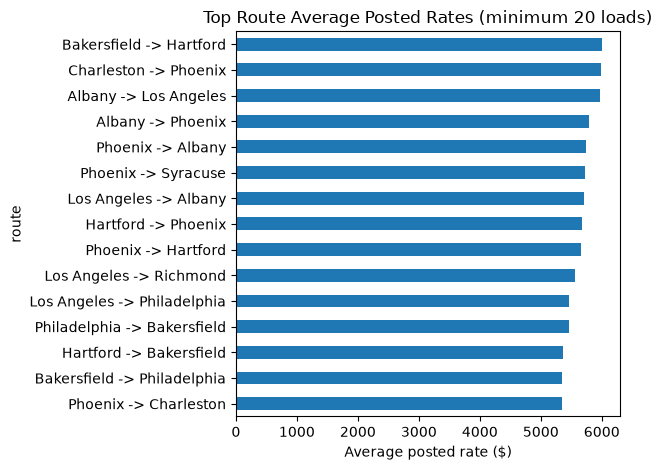

Monthly pricing:


,count,mean,median
date,,,
2025-01,4918,2255.967048,1915.200
2025-02,4337,2273.804801,1994.250
2025-03,5036,2372.268092,2022.920
2025-04,4819,2372.162308,2044.240
2025-05,4913,2421.776342,2065.510
2025-06,4783,2497.030115,2120.220
2025-07,4912,2415.162030,2059.145
2025-08,4759,2338.407661,2015.730
2025-09,4670,2406.374013,2057.130


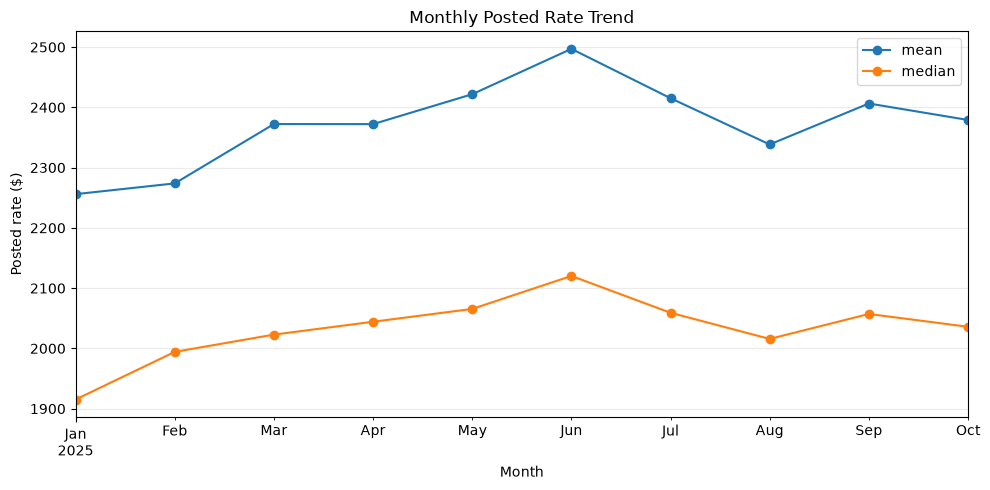

           distance   posted_rate  rate_per_mile
count  48000.000000  48000.000000   48000.000000
mean    1135.856654   2373.980682       2.215347
std      728.564416   1486.493245       0.583887
min       70.000000     57.220000       0.333709
25%      550.400000   1251.555000       1.986974
50%      953.300000   2030.760000       2.145348
75%     1645.525000   3330.750000       2.342696
max     3439.800000  25533.000000      14.125294


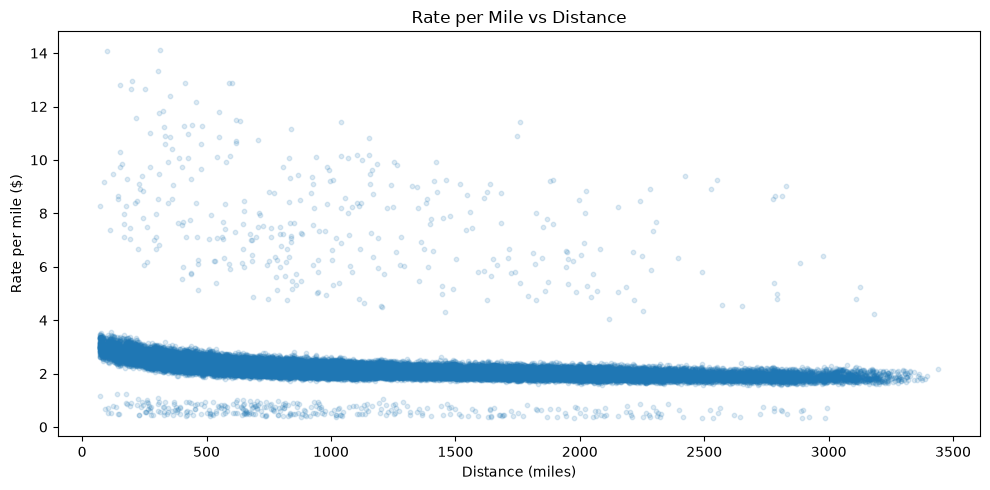

,count,mean,median
quote_decile,,,
"(0.691, 1.735]",4800,1473.648881,1038.495
"(1.735, 1.851]",4801,2598.360702,2304.070
"(1.851, 1.928]",4799,2679.470338,2430.050
"(1.928, 1.994]",4800,2640.319573,2297.865
"(1.994, 2.056]",4803,2639.470679,2297.590
"(2.056, 2.118]",4797,2635.321910,2270.130
"(2.118, 2.185]",4800,2665.780252,2353.040
"(2.185, 2.266]",4800,2674.993746,2401.185
"(2.266, 2.403]",4800,2469.526812,2051.335


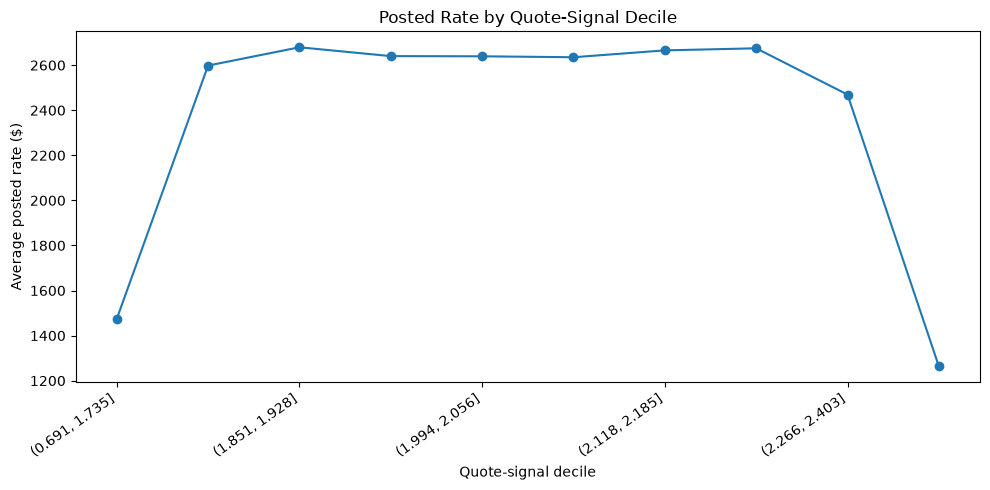

Without geographic features: MAE=$216.66, R²=0.7994
With geographic features:    MAE=$203.59, R²=0.8031
Target IQR upper bound: $6,449.54
Rate-per-mile IQR upper bound: $2.88
Candidate rows: 1,380


,load_id,pickup,delivery,distance,equipment,weight,posted_rate,rate_per_mile
12184,TR-012185,Bakersfield,Hartford,2829.8,Dry Van,33153.0,25533.00,9.022899
37764,TR-037765,Phoenix,Syracuse,2810.9,Dry Van,33674.0,24294.98,8.643132
1466,TR-001467,Los Angeles,Syracuse,2786.0,Reefer,30322.0,24140.21,8.664828
17371,TR-017372,Reno,Philadelphia,2777.6,Reefer,33158.0,23662.71,8.519121
26235,TR-026236,Charleston,Phoenix,2552.5,Dry Van,25665.0,23580.42,9.238167
28219,TR-028220,Tucson,Raleigh,2423.3,Dry Van,30972.0,22755.66,9.390360
3353,TR-003354,Phoenix,Charleston,2527.9,Reefer,36840.0,22534.65,8.914376
40171,TR-040172,Montgomery,Fresno,2283.4,Dry Van,32447.0,20361.89,8.917356
40096,TR-040097,Baltimore,Oklahoma City,1760.3,Reefer,29521.0,20132.37,11.436897
47298,TR-047299,Boston,Bakersfield,2979.1,Reefer,30585.0,19110.30,6.414790


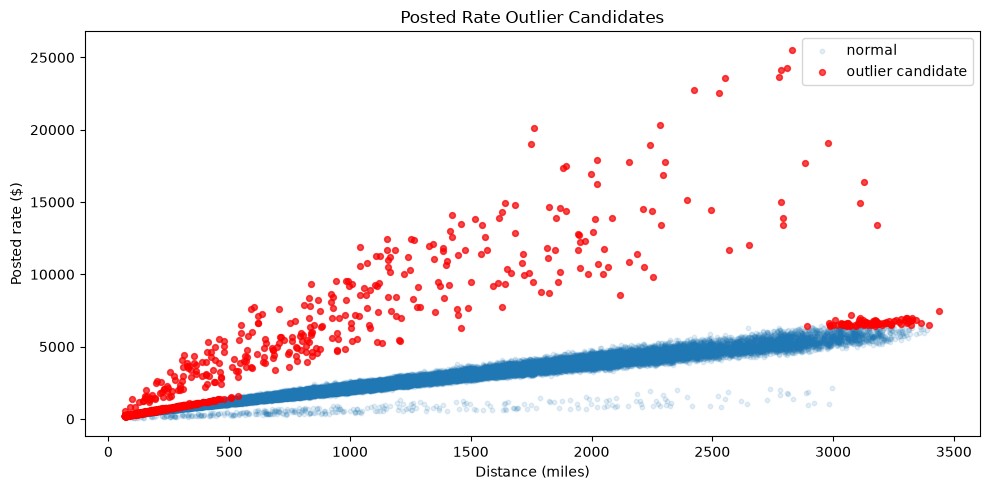

In [224]:
# Clean missing and invalid values, then analyze pricing behavior
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

train_clean = train.copy()
validation_clean = validation.copy()
eda = train_clean
validation_eda = validation_clean
eda['date'] = pd.to_datetime(eda['date'])
validation_eda['date'] = pd.to_datetime(validation_eda['date'])
# Apply the same geographic features to both cleaned datasets.
for frame in (eda, validation_eda):
    frame['great_circle_miles'] = haversine_miles(frame['pickup_lat'], frame['pickup_lon'], frame['delivery_lat'], frame['delivery_lon'])
    frame['distance_difference'] = frame['distance'] - frame['great_circle_miles']

# Negative weights are invalid. Preserve indicators, then impute invalid/missing values.
for frame in (eda, validation_eda):
    frame['weight_was_missing'] = frame['weight'].isna()
    frame['weight_was_negative'] = frame['weight'].lt(0)
    frame.loc[frame['weight'].lt(0), 'weight'] = np.nan

# Equipment means are learned from valid training weights and reused for validation.
weight_means = eda.loc[eda['weight'] >= 0].groupby('equipment')['weight'].mean()
overall_weight_median = eda.loc[eda['weight'] >= 0, 'weight'].median()
for frame in (eda, validation_eda):
    frame['weight'] = frame['weight'].fillna(frame['equipment'].map(weight_means))
    frame['weight'] = frame['weight'].fillna(overall_weight_median)

market_median = eda['market_index'].median()
for frame in (eda, validation_eda):
    frame['market_index_was_missing'] = frame['market_index'].isna()
    frame['market_index'] = frame['market_index'].fillna(market_median)

print('Training missing/invalid values after cleaning:')
print(eda[['weight', 'market_index']].isna().sum())
print('Training negative weights repaired:', int(eda['weight_was_negative'].sum()))
print('Validation negative weights repaired:', int(validation_eda['weight_was_negative'].sum()))

# Route-level pricing patterns. Require at least 20 observations for a stable comparison.
eda['route'] = eda['pickup'] + ' -> ' + eda['delivery']
route_summary = (eda.groupby('route')['posted_rate']
    .agg(loads='size', mean_rate='mean', median_rate='median')
    .query('loads >= 20')
    .sort_values('mean_rate', ascending=False))
print('Highest-rate routes with at least 20 loads:')
display(route_summary.head(15))
print('Lowest-rate routes with at least 20 loads:')
display(route_summary.sort_values('mean_rate').head(15))

plt.figure(figsize=(11, 6))
route_summary.head(15).sort_values('mean_rate').plot.barh(y='mean_rate', legend=False)
plt.title('Top Route Average Posted Rates (minimum 20 loads)')
plt.xlabel('Average posted rate ($)')
plt.tight_layout()
plt.show()

# Monthly trends.
monthly = eda.groupby(eda['date'].dt.to_period('M'))['posted_rate'].agg(['count', 'mean', 'median'])
print('Monthly pricing:')
display(monthly)
monthly[['mean', 'median']].plot(figsize=(10, 5), marker='o')
plt.title('Monthly Posted Rate Trend')
plt.xlabel('Month')
plt.ylabel('Posted rate ($)')
plt.grid(axis='y', alpha=.25)
plt.tight_layout()
plt.show()

# Rate-per-mile behavior.
eda['rate_per_mile'] = eda['posted_rate'] / eda['distance']
print(eda[['distance', 'posted_rate', 'rate_per_mile']].describe())
plt.figure(figsize=(10, 5))
plt.scatter(eda['distance'], eda['rate_per_mile'], alpha=.15, s=10)
plt.title('Rate per Mile vs Distance')
plt.xlabel('Distance (miles)')
plt.ylabel('Rate per mile ($)')
plt.tight_layout()
plt.show()

# Quote signal: decile averages reveal nonlinear effects better than correlation alone.
eda['quote_decile'] = pd.qcut(eda['quote_signal'], q=10, duplicates='drop')
quote_summary = eda.groupby('quote_decile', observed=True)['posted_rate'].agg(['count', 'mean', 'median'])
display(quote_summary)
quote_summary['mean'].plot(figsize=(10, 5), marker='o')
plt.title('Posted Rate by Quote-Signal Decile')
plt.xlabel('Quote-signal decile')
plt.ylabel('Average posted rate ($)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

# Geographic feature test: compare the same model with and without coordinates.
def haversine_miles(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = (np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2)
    return 3958.8 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

model_data = eda.copy()
model_data['great_circle_miles'] = haversine_miles(model_data['pickup_lat'], model_data['pickup_lon'], model_data['delivery_lat'], model_data['delivery_lon'])
model_data['day_number'] = (model_data['date'] - pd.Timestamp('2025-01-01')).dt.days
model_data['month'] = model_data['date'].dt.month
model_data['day_of_week'] = model_data['date'].dt.dayofweek
model_data['equipment'] = pd.Categorical(model_data['equipment']).codes
base_cols = ['distance', 'weight', 'market_index', 'quote_signal', 'month', 'day_of_week']
geo_cols = ['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'great_circle_miles']
cutoff = pd.Timestamp('2025-10-01')
fit = model_data['date'] < cutoff
def evaluate(columns):
    m = HistGradientBoostingRegressor(max_iter=180, learning_rate=.05, max_leaf_nodes=31, min_samples_leaf=20, random_state=42)
    m.fit(model_data.loc[fit, columns], model_data.loc[fit, 'posted_rate'])
    pred = m.predict(model_data.loc[~fit, columns])
    return mean_absolute_error(model_data.loc[~fit, 'posted_rate'], pred), r2_score(model_data.loc[~fit, 'posted_rate'], pred)

base_metrics = evaluate(base_cols)
geo_metrics = evaluate(base_cols + geo_cols)
print(f'Without geographic features: MAE=${base_metrics[0]:,.2f}, R²={base_metrics[1]:.4f}')
print(f'With geographic features:    MAE=${geo_metrics[0]:,.2f}, R²={geo_metrics[1]:.4f}')

# Target-outlier candidates: flag, inspect, do not automatically delete.
q1, q3 = eda['posted_rate'].quantile([.25, .75])
target_upper = q3 + 1.5 * (q3 - q1)
rpm_q1, rpm_q3 = eda['rate_per_mile'].quantile([.25, .75])
rpm_upper = rpm_q3 + 1.5 * (rpm_q3 - rpm_q1)
eda['target_outlier_candidate'] = eda['posted_rate'] > target_upper
eda['rate_per_mile_outlier_candidate'] = eda['rate_per_mile'] > rpm_upper
outliers = eda[eda['target_outlier_candidate'] | eda['rate_per_mile_outlier_candidate']].copy()
print(f'Target IQR upper bound: ${target_upper:,.2f}')
print(f'Rate-per-mile IQR upper bound: ${rpm_upper:,.2f}')
print(f'Candidate rows: {len(outliers):,}')
display(outliers.sort_values('posted_rate', ascending=False)[['load_id', 'pickup', 'delivery', 'distance', 'equipment', 'weight', 'posted_rate', 'rate_per_mile']].head(25))

plt.figure(figsize=(10, 5))
plt.scatter(eda['distance'], eda['posted_rate'], alpha=.12, s=10, label='normal')
plt.scatter(outliers['distance'], outliers['posted_rate'], color='red', alpha=.7, s=18, label='outlier candidate')
plt.title('Posted Rate Outlier Candidates')
plt.xlabel('Distance (miles)')
plt.ylabel('Posted rate ($)')
plt.legend()
plt.tight_layout()
plt.show()

In [225]:
eda['weight'].isna().sum()

np.int64(0)

In [226]:
eda['market_index'].isna().sum()

np.int64(0)

In [227]:
# Step 1: prepare model features from the cleaned EDA copies
analysis_columns = ['load_id', 'posted_rate', 'route', 'rate_per_mile', 'quote_decile', 'target_outlier_candidate', 'rate_per_mile_outlier_candidate']
y = eda['posted_rate'].copy()
X = eda.drop(columns=analysis_columns, errors='ignore')
X_validation = validation_eda.drop(columns=analysis_columns, errors='ignore')

In [228]:
# Step 2: create date features and remove the raw date column
for data in [X, X_validation]:
    data['month'] = data['date'].dt.month
    data['day_of_month'] = data['date'].dt.day
    data['day_of_week'] = data['date'].dt.dayofweek
    data['day_number'] = (data['date'] - pd.Timestamp('2025-01-01')).dt.days
X = X.drop(columns=['date'])
X_validation = X_validation.drop(columns=['date'])

In [229]:
# Step 3: encode categorical columns
categorical_columns = ['pickup', 'delivery', 'equipment']
X = pd.get_dummies(X, columns=categorical_columns, dtype=float)
X_validation = pd.get_dummies(X_validation, columns=categorical_columns, dtype=float)

In [230]:
# Step 4: align validation columns with training columns
X_validation = X_validation.reindex(columns=X.columns, fill_value=0)
print('Training feature columns:', X.shape[1])
print('Validation feature columns:', X_validation.shape[1])

Training feature columns: 148
Validation feature columns: 148


In [231]:
# Step 5: handle any remaining missing or infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X_validation = X_validation.replace([np.inf, -np.inf], np.nan)
print('Missing before fill:', int(X.isna().sum().sum()), int(X_validation.isna().sum().sum()))
X = X.fillna(0)
X_validation = X_validation.fillna(0)
print('Missing after fill:', int(X.isna().sum().sum()), int(X_validation.isna().sum().sum()))

Missing before fill: 0 0
Missing after fill: 0 0


In [232]:
# Step 6: create a time-based validation split
dates = eda['date']
fit_rows = dates < pd.Timestamp('2025-10-01')
test_rows = dates >= pd.Timestamp('2025-10-01')
X_train = X.loc[fit_rows]
X_test = X.loc[test_rows]
y_train = y.loc[fit_rows]
y_test = y.loc[test_rows]
print('Model training rows:', len(X_train))
print('Time-validation rows:', len(X_test))

Model training rows: 43147
Time-validation rows: 4853


In [233]:
# Final model: train, evaluate, refit, and create submission files
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=350,
    max_leaf_nodes=63,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=42
)
model.fit(X_train, y_train)
test_pred = np.maximum(model.predict(X_test), 0.01)
print(f'Time holdout MAE: ${mean_absolute_error(y_test, test_pred):,.2f}')
print(f'Time holdout RMSE: ${mean_squared_error(y_test, test_pred) ** 0.5:,.2f}')
print(f'Time holdout R2: {r2_score(y_test, test_pred):.4f}')

# Refit using every cleaned labeled row.
model.fit(X, y)
validation_pred = np.maximum(model.predict(X_validation), 0.01)
predictions = pd.DataFrame({'load_id': validation_eda['load_id'], 'predicted_rate': validation_pred})
predictions.to_csv('validation_predictions.csv', index=False)

# Predict the fixed December chart scenario using the same feature logic.
december_inputs = pd.read_csv(DECEMBER_FILE)
december_model = december_inputs.drop(columns=['predicted_rate'], errors='ignore').copy()
city_coordinates = train_clean.groupby('pickup')[['pickup_lat', 'pickup_lon']].first()
delivery_coordinates = train_clean.groupby('delivery')[['delivery_lat', 'delivery_lon']].first()
december_model['pickup_lat'] = december_model['pickup'].map(city_coordinates['pickup_lat'])
december_model['pickup_lon'] = december_model['pickup'].map(city_coordinates['pickup_lon'])
december_model['delivery_lat'] = december_model['delivery'].map(delivery_coordinates['delivery_lat'])
december_model['delivery_lon'] = december_model['delivery'].map(delivery_coordinates['delivery_lon'])
december_model['date'] = pd.to_datetime(december_model['date'])
december_model['great_circle_miles'] = haversine_miles(december_model['pickup_lat'], december_model['pickup_lon'], december_model['delivery_lat'], december_model['delivery_lon'])
december_model['distance_difference'] = december_model['distance'] - december_model['great_circle_miles']
december_model['month'] = december_model['date'].dt.month
december_model['day_of_month'] = december_model['date'].dt.day
december_model['day_of_week'] = december_model['date'].dt.dayofweek
december_model['day_number'] = (december_model['date'] - pd.Timestamp('2025-01-01')).dt.days
december_model = december_model.drop(columns=['date'])
december_model = pd.get_dummies(december_model, columns=['pickup', 'delivery', 'equipment'], dtype=float)
december_model = december_model.reindex(columns=X.columns, fill_value=0)
december_model = december_model.replace([np.inf, -np.inf], np.nan).fillna(0)
december_inputs['predicted_rate'] = np.maximum(model.predict(december_model), 0.01)
december_inputs.to_csv(DECEMBER_FILE, index=False)
print('Wrote validation_predictions.csv and december-chart-inputs.csv')

Time holdout MAE: $193.69
Time holdout RMSE: $676.30
Time holdout R2: 0.8042
Wrote validation_predictions.csv and december-chart-inputs.csv


In [234]:
# Model comparison setup
from catboost import CatBoostRegressor

cat_drop = ['load_id', 'posted_rate', 'rate_per_mile', 'quote_decile', 'target_outlier_candidate', 'rate_per_mile_outlier_candidate']
cat_columns = ['pickup', 'delivery', 'equipment', 'route']

def make_cat_features(frame):
    data = frame.copy()
    data['date'] = pd.to_datetime(data['date'])
    data['route'] = data['pickup'].astype(str) + '__' + data['delivery'].astype(str)
    data['month'] = data['date'].dt.month
    data['day_of_month'] = data['date'].dt.day
    data['day_of_week'] = data['date'].dt.dayofweek
    data['day_number'] = (data['date'] - pd.Timestamp('2025-01-01')).dt.days
    data = data.drop(columns=cat_drop + ['date'], errors='ignore')
    for column in cat_columns:
        data[column] = data[column].fillna('Unknown').astype(str)
    numeric = data.columns.difference(cat_columns)
    data[numeric] = data[numeric].replace([np.inf, -np.inf], np.nan).fillna(0)
    return data

cat_X = make_cat_features(eda)
cat_validation = make_cat_features(validation_eda)
cat_validation = cat_validation.reindex(columns=cat_X.columns, fill_value=0)
for column in cat_columns:
    cat_X[column] = cat_X[column].astype(str)
    cat_validation[column] = cat_validation[column].astype(str)

In [235]:
# Train candidate models on the time-based training split
cat_params = dict(iterations=700, depth=8, learning_rate=0.05, loss_function='RMSE', l2_leaf_reg=5, random_seed=42, verbose=False, thread_count=4)
cat_direct = CatBoostRegressor(**cat_params)
cat_direct.fit(cat_X.loc[fit_rows], y.loc[fit_rows], cat_features=cat_columns)
cat_direct_test = np.maximum(cat_direct.predict(cat_X.loc[test_rows]), 0.01)
cat_log = CatBoostRegressor(**cat_params)
cat_log.fit(cat_X.loc[fit_rows], np.log1p(y.loc[fit_rows]), cat_features=cat_columns)
cat_log_test = np.maximum(np.expm1(cat_log.predict(cat_X.loc[test_rows])), 0.01)

In [236]:
# Select the best model, refit it on all labeled data, and write validation predictions
scores = {
    'hist_gradient_boosting': mean_absolute_error(y_test, test_pred),
    'catboost_direct': mean_absolute_error(y_test, cat_direct_test),
    'catboost_log': mean_absolute_error(y_test, cat_log_test)
}
print('Validation MAE comparison:')
for name, score in scores.items():
    print(f'{name}: ${score:,.2f}')
best_model_name = min(scores, key=scores.get)
print('Selected model:', best_model_name)

if best_model_name == 'hist_gradient_boosting':
    final_validation_pred = validation_pred
else:
    selected_cat = cat_direct if best_model_name == 'catboost_direct' else cat_log
    selected_cat.fit(cat_X, np.log1p(y) if best_model_name == 'catboost_log' else y, cat_features=cat_columns)
    raw_prediction = selected_cat.predict(cat_validation)
    final_validation_pred = np.maximum(np.expm1(raw_prediction) if best_model_name == 'catboost_log' else raw_prediction, 0.01)

pd.DataFrame({'load_id': validation_eda['load_id'], 'predicted_rate': final_validation_pred}).to_csv('validation_predictions.csv', index=False)

Validation MAE comparison:
hist_gradient_boosting: $193.69
catboost_direct: $153.97
catboost_log: $127.09
Selected model: catboost_log


In [237]:
# Use the selected model for the December chart inputs
december_inputs = pd.read_csv(DECEMBER_FILE)
december_raw = december_inputs.drop(columns=['predicted_rate'], errors='ignore').copy()
pickup_coordinates = train_clean.groupby('pickup')[['pickup_lat', 'pickup_lon']].first()
delivery_coordinates = train_clean.groupby('delivery')[['delivery_lat', 'delivery_lon']].first()
december_raw['pickup_lat'] = december_raw['pickup'].map(pickup_coordinates['pickup_lat'])
december_raw['pickup_lon'] = december_raw['pickup'].map(pickup_coordinates['pickup_lon'])
december_raw['delivery_lat'] = december_raw['delivery'].map(delivery_coordinates['delivery_lat'])
december_raw['delivery_lon'] = december_raw['delivery'].map(delivery_coordinates['delivery_lon'])
december_raw['weight_was_missing'] = False
december_raw['weight_was_negative'] = False
december_raw['market_index'] = 0.0
december_raw['market_index_was_missing'] = True
if best_model_name == 'hist_gradient_boosting':
    december_inputs['predicted_rate'] = np.maximum(model.predict(december_model), 0.01)
else:
    december_cat = make_cat_features(december_raw).reindex(columns=cat_X.columns, fill_value=0)
    for column in cat_columns:
        december_cat[column] = december_cat[column].astype(str)
    december_raw_prediction = selected_cat.predict(december_cat)
    december_inputs['predicted_rate'] = np.maximum(np.expm1(december_raw_prediction) if best_model_name == 'catboost_log' else december_raw_prediction, 0.01)
december_inputs.to_csv(DECEMBER_FILE, index=False)
print('Final validation_predictions.csv and december-chart-inputs.csv written.')

Final validation_predictions.csv and december-chart-inputs.csv written.
